# Metric Collection

In [15]:
from stable_baselines3 import A2C, DQN, PPO
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

import gymnasium as gym
import ale_py
gym.register_envs(ale_py)

import os
import glob

import numpy as np
import pandas as pd

model_path = "models/"

In [2]:
def evaluate_model(model, env, n_episodes=10, deterministic=True):
    rewards, lengths = evaluate_policy(
        model,
        env,
        n_eval_episodes=n_episodes,
        deterministic=deterministic,
        return_episode_rewards=True,
    )
    
    rewards = np.array(rewards)
    lengths = np.array(lengths)

    return {
        "mean_reward": rewards.mean(),
        "std_reward": rewards.std(),
        "min_reward": rewards.min(),
        "max_reward": rewards.max(),
        "median_reward": np.median(rewards),
        "mean_ep_length": lengths.mean(),
        "n_episodes": n_episodes,
        "rewards": rewards,
        "lengths": lengths,
    }

## Galaxian

In [3]:
vec_env = make_atari_env(
    "ALE/Galaxian-v5",
    n_envs=4,
    seed=0,
    wrapper_kwargs=dict(terminal_on_life_loss=False)
)

vec_env = VecFrameStack(vec_env, n_stack=4)

A.L.E: Arcade Learning Environment (version 0.11.2+unknown)
[Powered by Stella]


### DQN

In [6]:
filenames = glob.glob(os.path.join(model_path, "dqn_pong_*"))

dqn_galax_results = {}
for f in filenames:
    model = DQN.load(f, env=vec_env)

    result = evaluate_model(model, vec_env)
    print(result)

    model_name = f.split("_")[-1].split(".")[0]
    dqn_galax_results[model_name] = result


Wrapping the env in a VecTransposeImage.


/home/cynthia/csci/reinforcement/env/lib/python3.14/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 22.59GB > 21.60GB
  warnings.warn(


{'mean_reward': np.float64(1090.0), 'std_reward': np.float64(496.60849771223207), 'min_reward': np.float64(180.0), 'max_reward': np.float64(1810.0), 'median_reward': np.float64(1160.0), 'mean_ep_length': np.float64(1276.8), 'n_episodes': 10, 'rewards': array([1110., 1120., 1410.,  300., 1260.,  180.,  870., 1200., 1810.,
       1640.]), 'lengths': array([ 943, 1113, 1221,  351, 1433,  377,  783, 1123, 2809, 2615])}
Wrapping the env in a VecTransposeImage.


/home/cynthia/csci/reinforcement/env/lib/python3.14/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 22.59GB > 21.56GB
  warnings.warn(


{'mean_reward': np.float64(636.0), 'std_reward': np.float64(218.3666641225258), 'min_reward': np.float64(240.0), 'max_reward': np.float64(940.0), 'median_reward': np.float64(690.0), 'mean_ep_length': np.float64(447.8), 'n_episodes': 10, 'rewards': array([480., 430., 650., 890., 430., 240., 800., 940., 730., 770.]), 'lengths': array([329, 329, 431, 553, 329, 279, 543, 719, 435, 531])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(745.0), 'std_reward': np.float64(214.72074888095935), 'min_reward': np.float64(340.0), 'max_reward': np.float64(1190.0), 'median_reward': np.float64(720.0), 'mean_ep_length': np.float64(541.2), 'n_episodes': 10, 'rewards': array([ 630.,  650.,  660.,  340.,  850.,  780.,  840., 1190.,  600.,
        910.]), 'lengths': array([361, 465, 529, 357, 727, 543, 519, 877, 431, 603])}
Wrapping the env in a VecTransposeImage.


...

{'mean_reward': np.float64(3047.0), 'std_reward': np.float64(1406.0444516443995), 'min_reward': np.float64(1370.0), 'max_reward': np.float64(5350.0), 'median_reward': np.float64(2810.0), 'mean_ep_length': np.float64(1548.4), 'n_episodes': 10, 'rewards': array([1750., 1890., 1380., 1370., 4110., 4260., 4740., 2440., 5350.,
       3180.]), 'lengths': array([ 945, 1057,  723,  831, 2023, 2507, 2035, 1247, 2667, 1449])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(2536.0), 'std_reward': np.float64(746.0321708880924), 'min_reward': np.float64(1400.0), 'max_reward': np.float64(3490.0), 'median_reward': np.float64(2960.0), 'mean_ep_length': np.float64(1502.0), 'n_episodes': 10, 'rewards': array([1400., 2900., 1980., 3080., 1870., 1400., 3020., 3120., 3100.,
       3490.]), 'lengths': array([ 975, 1343, 1375, 1635, 1293,  953, 1685, 1963, 1711, 2087])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(2578.0), 'std_reward': np.float64(686.3643347377542)

/home/cynthia/csci/reinforcement/env/lib/python3.14/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 22.59GB > 22.13GB
  warnings.warn(


{'mean_reward': np.float64(3346.0), 'std_reward': np.float64(1362.278972897989), 'min_reward': np.float64(1480.0), 'max_reward': np.float64(5690.0), 'median_reward': np.float64(3340.0), 'mean_ep_length': np.float64(1615.2), 'n_episodes': 10, 'rewards': array([1560., 2840., 2370., 3840., 2370., 4530., 3940., 4840., 5690.,
       1480.]), 'lengths': array([ 735, 1421, 1163, 2007,  839, 2369, 1921, 2473, 2453,  771])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(2248.0), 'std_reward': np.float64(713.2152550247365), 'min_reward': np.float64(1560.0), 'max_reward': np.float64(3620.0), 'median_reward': np.float64(2035.0), 'mean_ep_length': np.float64(1075.6), 'n_episodes': 10, 'rewards': array([1650., 1640., 1560., 2500., 1590., 1600., 2760., 3620., 2420.,
       3140.]), 'lengths': array([ 623,  783,  939, 1185,  885,  719, 1283, 1685,  969, 1685])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(3916.0), 'std_reward': np.float64(1591.7612886359561)

/home/cynthia/csci/reinforcement/env/lib/python3.14/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 22.59GB > 22.57GB
  warnings.warn(


{'mean_reward': np.float64(3922.0), 'std_reward': np.float64(903.302828513229), 'min_reward': np.float64(2900.0), 'max_reward': np.float64(5520.0), 'median_reward': np.float64(3715.0), 'mean_ep_length': np.float64(1890.4), 'n_episodes': 10, 'rewards': array([3370., 3160., 3900., 5420., 2900., 2900., 4210., 4310., 3530.,
       5520.]), 'lengths': array([1637, 1809, 2053, 2387, 1225, 1257, 1945, 2073, 1715, 2803])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(2614.0), 'std_reward': np.float64(1104.2843836621073), 'min_reward': np.float64(1300.0), 'max_reward': np.float64(4270.0), 'median_reward': np.float64(2490.0), 'mean_ep_length': np.float64(1572.6), 'n_episodes': 10, 'rewards': array([1530., 1520., 2280., 3860., 4270., 2700., 1380., 3730., 3570.,
       1300.]), 'lengths': array([ 711, 1249, 1347, 2253, 2287, 1463, 1085, 2219, 2153,  959])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(2754.0), 'std_reward': np.float64(793.3750689302002),

In [7]:
import matplotlib.pyplot as plt

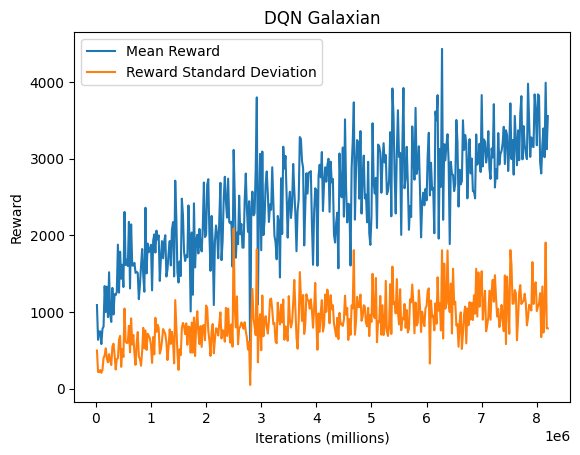

In [36]:
mean_points = []
std_points = []
x_points = []
for k in dqn_galax_results.keys():
    mean_points.append(dqn_galax_results[k]["mean_reward"])
    std_points.append(dqn_galax_results[k]["std_reward"])
    x_points.append(np.float64(k))

plt.title("DQN Galaxian")
plt.xlabel("Iterations (millions)")
plt.ylabel("Reward")

plt.plot(x_points, mean_points)
plt.plot(x_points, std_points)
plt.legend(labels=["Mean Reward", "Reward Standard Deviation"])
plt.savefig("metrics/dqn_galaxian.png")
plt.show()

result_df = pd.DataFrame({"index": x_points, "mean": mean_points, "std": std_points})
result_df.to_csv("metrics/dqn_galaxian.csv")

### A2C

In [24]:
filenames = glob.glob(os.path.join(model_path, "a2c_pong*"))

a2c_galax_results = {}
counter = 0
for f in filenames:
    # only run half of them
    counter += 1
    if (counter % 2 == 0):
        continue

    model = A2C.load(f, env=vec_env)

    result = evaluate_model(model, vec_env)
    print(result)

    model_name = f.split("_")[-1].split(".")[0]
    a2c_galax_results[model_name] = result


Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(1003.0), 'std_reward': np.float64(347.4492768736179), 'min_reward': np.float64(410.0), 'max_reward': np.float64(1700.0), 'median_reward': np.float64(940.0), 'mean_ep_length': np.float64(691.0), 'n_episodes': 10, 'rewards': array([ 830.,  990., 1420., 1180.,  680.,  410.,  880., 1700., 1050.,
        890.]), 'lengths': array([ 499,  687,  885,  957,  523,  363,  597, 1091,  771,  537])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(1559.0), 'std_reward': np.float64(584.4219366177146), 'min_reward': np.float64(670.0), 'max_reward': np.float64(2650.0), 'median_reward': np.float64(1365.0), 'mean_ep_length': np.float64(1269.4), 'n_episodes': 10, 'rewards': array([ 670., 1350., 2650., 1250., 2180., 1630., 1140., 1380., 2250.,
       1090.]), 'lengths': array([ 559, 1103, 1615, 1089, 1759, 1085,  967, 1893, 1613, 1011])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(1575.0), 'std_re

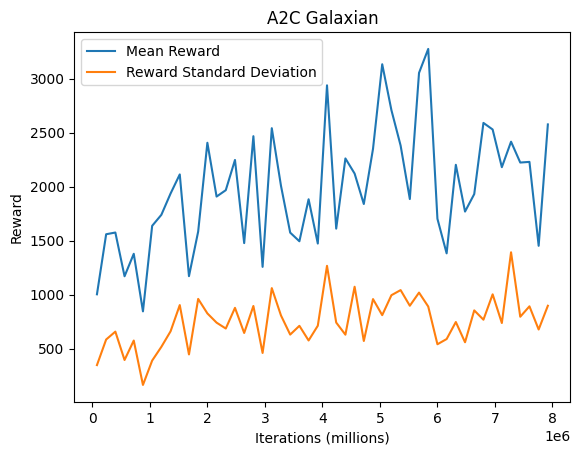

In [38]:
mean_points = []
std_points = []
x_points = []
for k in a2c_galax_results.keys():
    mean_points.append(a2c_galax_results[k]["mean_reward"])
    std_points.append(a2c_galax_results[k]["std_reward"])
    x_points.append(np.float64(k))

plt.title("A2C Galaxian")
plt.xlabel("Iterations (millions)")
plt.ylabel("Reward")

line1 = plt.plot(x_points, mean_points)
line2 = plt.plot(x_points, std_points)
plt.legend(labels=["Mean Reward", "Reward Standard Deviation"])
plt.savefig("metrics/a2c_galaxian.png")
plt.show()

result_df = pd.DataFrame({"index": x_points, "mean": mean_points, "std": std_points})
result_df.to_csv("metrics/a2c_galaxian.csv")

### PPO

In [26]:
filenames = glob.glob(os.path.join(model_path, "ppo_pong_*"))

ppo_galax_results = {}
counter = 0
for f in filenames:
    # skip half of them
    counter += 1
    if counter % 2 == 0:
        continue

    model = PPO.load(f, env=vec_env)

    result = evaluate_model(model, vec_env)
    print(result)

    model_name = f.split("_")[-1].split(".")[0]
    ppo_galax_results[model_name] = result


Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(822.0), 'std_reward': np.float64(392.21932639787144), 'min_reward': np.float64(270.0), 'max_reward': np.float64(1370.0), 'median_reward': np.float64(870.0), 'mean_ep_length': np.float64(778.6), 'n_episodes': 10, 'rewards': array([ 270.,  360.,  700., 1370.,  310., 1370., 1180.,  860.,  880.,
        920.]), 'lengths': array([ 317,  423,  879, 1133,  451, 1455,  953,  765,  599,  811])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(1063.0), 'std_reward': np.float64(447.4382638979371), 'min_reward': np.float64(540.0), 'max_reward': np.float64(1970.0), 'median_reward': np.float64(895.0), 'mean_ep_length': np.float64(1000.6), 'n_episodes': 10, 'rewards': array([ 800.,  910., 1170.,  720.,  880.,  540.,  590., 1970., 1520.,
       1530.]), 'lengths': array([ 731,  865,  987, 1025,  663,  669,  607, 1721, 1453, 1285])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(1357.0), 'std_rew

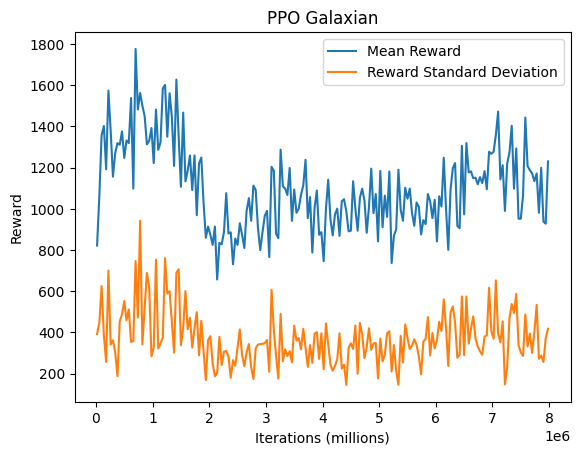

In [39]:
mean_points = []
std_points = []
x_points = []
for k in ppo_galax_results.keys():
    mean_points.append(ppo_galax_results[k]["mean_reward"])
    std_points.append(ppo_galax_results[k]["std_reward"])
    x_points.append(np.float64(k))

plt.title("PPO Galaxian")
plt.xlabel("Iterations (millions)")
plt.ylabel("Reward")

line1 = plt.plot(x_points, mean_points)
line2 = plt.plot(x_points, std_points)
plt.legend(labels=["Mean Reward", "Reward Standard Deviation"])
plt.savefig("metrics/ppo_galaxian.png")
plt.show()

result_df = pd.DataFrame({"index": x_points, "mean": mean_points, "std": std_points})
result_df.to_csv("metrics/ppo_galaxian.csv")

## Centipede

In [28]:
vec_env = make_atari_env(
    "ALE/Centipede-v5",
    n_envs=4,
    seed=0,
    wrapper_kwargs=dict(terminal_on_life_loss=False)
)

vec_env = VecFrameStack(vec_env, n_stack=4)

### DQN

In [29]:
filenames = glob.glob(os.path.join(model_path, "dqn_centipede*"))

dqn_centipede_results = {}
counter = 0
for f in filenames:
    counter += 1
    if counter % 2 == 0:
        continue

    model = DQN.load(f, env=vec_env)

    result = evaluate_model(model, vec_env)
    print(result)

    model_name = f.split("_")[-1].split(".")[0]
    dqn_centipede_results[model_name] = result


Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(5374.4), 'std_reward': np.float64(3952.2883801666094), 'min_reward': np.float64(849.0), 'max_reward': np.float64(16322.0), 'median_reward': np.float64(4700.0), 'mean_ep_length': np.float64(941.6), 'n_episodes': 10, 'rewards': array([ 4592.,  3982.,  5653.,  4808.,  2057.,  4426.,  6226., 16322.,
        4829.,   849.]), 'lengths': array([ 763,  761, 1117,  803,  915,  572,  750, 2422,  818,  495])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(4849.6), 'std_reward': np.float64(2976.082532457727), 'min_reward': np.float64(2126.0), 'max_reward': np.float64(13085.0), 'median_reward': np.float64(4097.0), 'mean_ep_length': np.float64(841.5), 'n_episodes': 10, 'rewards': array([ 4569.,  4151.,  3835.,  2374.,  2994.,  5343.,  2126.,  5976.,
       13085.,  4043.]), 'lengths': array([ 818,  833,  890,  976,  521,  836,  446, 1075, 1263,  757])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.

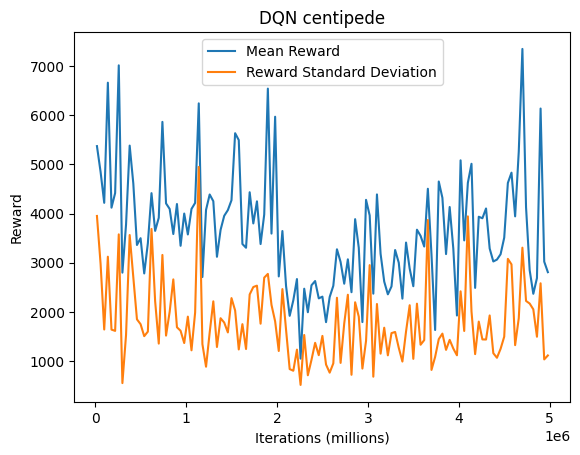

In [40]:
mean_points = []
std_points = []
x_points = []
for k in dqn_centipede_results.keys():
    mean_points.append(dqn_centipede_results[k]["mean_reward"])
    std_points.append(dqn_centipede_results[k]["std_reward"])
    x_points.append(np.float64(k))

plt.title("DQN centipede")
plt.xlabel("Iterations (millions)")
plt.ylabel("Reward")

plt.plot(x_points, mean_points)
plt.plot(x_points, std_points)
plt.legend(labels=["Mean Reward", "Reward Standard Deviation"])
plt.savefig("metrics/dqn_centipede.png")
plt.show()

result_df = pd.DataFrame({"index": x_points, "mean": mean_points, "std": std_points})
result_df.to_csv("metrics/dqn_centipede.csv")

### A2C

In [31]:
filenames = glob.glob(os.path.join(model_path, "a2c_centipede*"))

a2c_centipede_results = {}
counter = 0
for f in filenames:
    # only run half of them
    counter += 1
    if (counter % 2 == 0):
        continue

    model = A2C.load(f, env=vec_env)

    result = evaluate_model(model, vec_env)
    print(result)

    model_name = f.split("_")[-1].split(".")[0]
    a2c_centipede_results[model_name] = result


Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(4640.8), 'std_reward': np.float64(1432.3534340378424), 'min_reward': np.float64(2128.0), 'max_reward': np.float64(6389.0), 'median_reward': np.float64(4693.0), 'mean_ep_length': np.float64(915.5), 'n_episodes': 10, 'rewards': array([3205., 6272., 6272., 6389., 3253., 3801., 5702., 4693., 2128.,
       4693.]), 'lengths': array([ 741,  840,  840,  958,  529,  985, 1047, 1289,  637, 1289])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(2709.4), 'std_reward': np.float64(1180.0341689968134), 'min_reward': np.float64(1034.0), 'max_reward': np.float64(4869.0), 'median_reward': np.float64(2590.5), 'mean_ep_length': np.float64(1198.5), 'n_episodes': 10, 'rewards': array([1602., 3321., 3837., 1689., 4869., 1724., 1034., 2958., 3837.,
       2223.]), 'lengths': array([ 827, 1100, 1573,  820, 1643,  845,  939, 1057, 1573, 1608])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(2118.5), 's

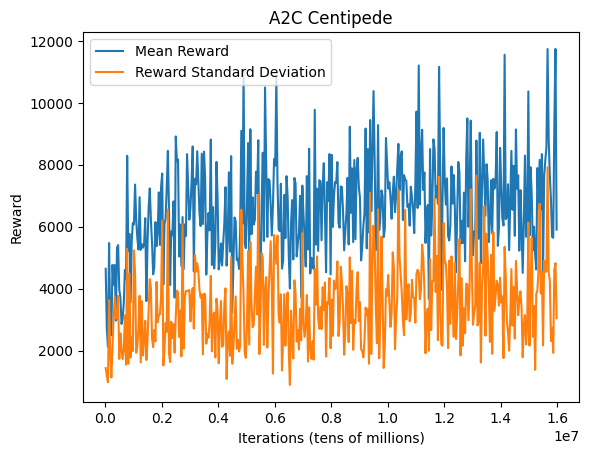

In [43]:
mean_points = []
std_points = []
x_points = []
for k in a2c_centipede_results.keys():
    mean_points.append(a2c_centipede_results[k]["mean_reward"])
    std_points.append(a2c_centipede_results[k]["std_reward"])
    x_points.append(np.float64(k))

plt.title("A2C Centipede")
plt.xlabel("Iterations (tens of millions)")
plt.ylabel("Reward")

plt.plot(x_points, mean_points)
plt.plot(x_points, std_points)
plt.legend(labels=["Mean Reward", "Reward Standard Deviation"])
plt.savefig("metrics/a2c_centipede.png")
plt.show()

result_df = pd.DataFrame({"index": x_points, "mean": mean_points, "std": std_points})
result_df.to_csv("metrics/a2c_centipede.csv")

### PPO

In [33]:
filenames = glob.glob(os.path.join(model_path, "ppo_centipede*"))

ppo_centipede_results = {}
counter = 0
for f in filenames:
    # skip half of them
    counter += 1
    if counter % 2 == 0:
        continue

    model = PPO.load(f, env=vec_env)

    result = evaluate_model(model, vec_env)
    print(result)

    model_name = f.split("_")[-1].split(".")[0]
    ppo_centipede_results[model_name] = result


Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(2903.5), 'std_reward': np.float64(1047.5108829983583), 'min_reward': np.float64(1203.0), 'max_reward': np.float64(4490.0), 'median_reward': np.float64(2718.5), 'mean_ep_length': np.float64(922.1), 'n_episodes': 10, 'rewards': array([1576., 2785., 2403., 2652., 1203., 2586., 2982., 3941., 4490.,
       4417.]), 'lengths': array([ 687,  848, 1013, 1217,  748,  996,  927,  840,  803, 1142])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(2796.4), 'std_reward': np.float64(1325.5463930017688), 'min_reward': np.float64(1146.0), 'max_reward': np.float64(6080.0), 'median_reward': np.float64(2570.0), 'mean_ep_length': np.float64(746.1), 'n_episodes': 10, 'rewards': array([2930., 3616., 2210., 6080., 3013., 3370., 1977., 1666., 1956.,
       1146.]), 'lengths': array([ 631,  725, 1014, 1095,  660,  784,  641,  772,  552,  587])}
Wrapping the env in a VecTransposeImage.
{'mean_reward': np.float64(3966.7), 'st

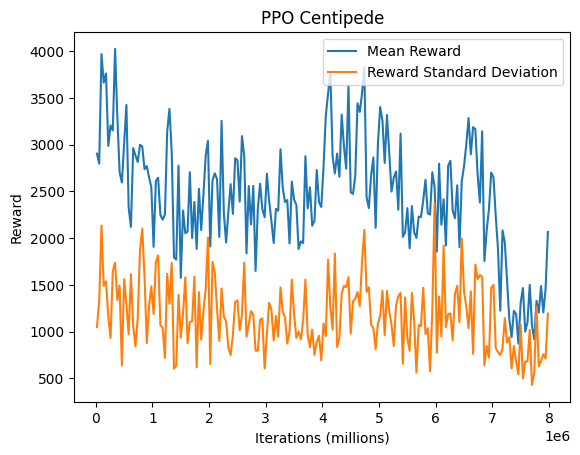

In [42]:
mean_points = []
std_points = []
x_points = []
for k in ppo_centipede_results.keys():
    mean_points.append(ppo_centipede_results[k]["mean_reward"])
    std_points.append(ppo_centipede_results[k]["std_reward"])
    x_points.append(np.float64(k))

plt.title("PPO Centipede")
plt.xlabel("Iterations (millions)")
plt.ylabel("Reward")

plt.plot(x_points, mean_points)
plt.plot(x_points, std_points)
plt.legend(labels=["Mean Reward", "Reward Standard Deviation"])
plt.savefig("metrics/ppo_centipede.png")
plt.show()

result_df = pd.DataFrame({"index": x_points, "mean": mean_points, "std": std_points})
result_df.to_csv("metrics/ppo_centipede.csv")